In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

In [2]:
digits = datasets.load_digits()
X = digits.data
Y = digits.target

In [3]:
valuesY, countsY = np.unique(Y, return_counts=True)
K = np.shape(countsY)[0]
countsY

array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180])

In [4]:
# rescaled digits to [0,1]
X = X / np.max(X)

In [5]:
# compute centroids
n, d = X.shape
Xbar = np.mean(X, 0)
C = np.zeros([K, d])
M = np.zeros([K, d])

for k in range(K):
    C[k,:] = np.mean(X[Y==k,:], 0)
    M[k,:] = (np.mean(X[Y==k,:],0) - Xbar)

In [6]:
# between and within scatter matrices
B = (M.T * countsY) @ M

tmp = np.zeros([n, d])
for i in range(n):
    tmp[i,:] = X[i,:] - C[Y[i],:]

W = tmp.T @ tmp

In [7]:
T = B + W
T2 = (X - Xbar).T @ (X - Xbar)
np.allclose(T, T2)

True

In [8]:
U, s, Vt = np.linalg.svd(W, full_matrices=False) 
sel = s > 1E-6

Winvhalf = (U[:,sel] * 1/np.sqrt(s[sel])) @ (Vt.T[:,sel]).T

In [9]:
#test = Winvhalf @ W @ Winvhalf
#UU, ss, VVt = np.linalg.svd(test)
#ss

In [10]:

#UU, ss, VVt = np.linalg.svd(test)
#ss
# np.max(abs(U[:,sel] - Vt[sel,:].T))
Q = Winvhalf @ B @ Winvhalf 
eigvals, Vtilde = np.linalg.eigh(Q)

# np.allclose(Vtilde @ np.diag(eigvals) @ Vtilde.T, Q)

In [11]:
# note that there exactly K-1 = 9 non-zero eigenvalues
eigvals 

array([-3.27424101e-13, -9.67395386e-14, -5.79269347e-14, -4.19773646e-14,
       -2.80852515e-14, -2.36294518e-14, -1.20781703e-14, -1.06997506e-14,
       -9.03500812e-15, -6.20273834e-15, -4.34801121e-15, -2.92431397e-15,
       -2.84603315e-15, -2.38755787e-15, -2.16905372e-15, -2.06340639e-15,
       -2.02016555e-15, -1.61987885e-15, -1.58974126e-15, -1.37228949e-15,
       -1.24615261e-15, -8.96644731e-16, -7.74760054e-16, -5.34506899e-16,
       -3.78586428e-16, -2.66857211e-16, -2.66818953e-16, -2.38389041e-16,
       -5.84220834e-17,  0.00000000e+00,  5.81499903e-17,  2.02301131e-16,
        2.87579450e-16,  4.26657955e-16,  5.98329115e-16,  8.63802458e-16,
        8.78744441e-16,  1.22963046e-15,  1.26796966e-15,  1.44723852e-15,
        1.64064063e-15,  1.95253267e-15,  2.06120496e-15,  2.56694451e-15,
        3.74129870e-15,  5.82809001e-15,  7.60801474e-15,  8.75937496e-15,
        1.14407719e-14,  1.36223680e-14,  3.35770191e-14,  5.04871882e-14,
        6.30982069e-14,  

In [12]:
# back-transform leading eigenvectors
Vfinal = Winvhalf @ Vtilde[:, -(K-1):]

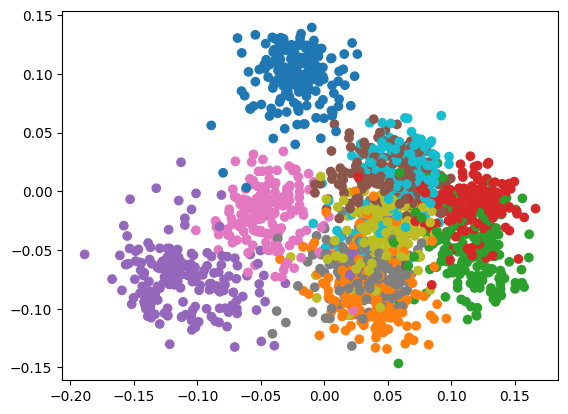

In [13]:
Z = X @ Vfinal[:, ::-1]
colors = plt.cm.tab10(np.arange(K))

# this plots the first two coordinates against each other 
plt.scatter(Z[:,0], Z[:,1], c = colors[Y])

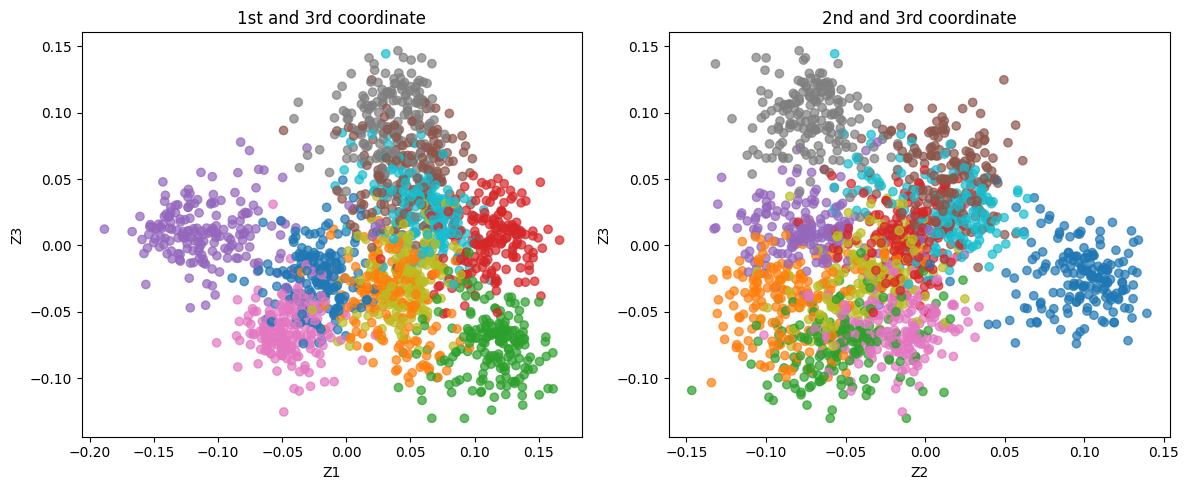

In [14]:
# altogether the 3 first coordinates will yield a decent separation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First scatterplot
axes[0].scatter(Z[:,0], Z[:,2], color=colors[Y], alpha=0.7)
axes[0].set_title("1st and 3rd coordinate")
axes[0].set_xlabel("Z1")
axes[0].set_ylabel("Z3")

# Second scatterplot
axes[1].scatter(Z[:,1], Z[:,2], color=colors[Y], alpha=0.7)
axes[1].set_title("2nd and 3rd coordinate")
axes[1].set_xlabel("Z2")
axes[1].set_ylabel("Z3")

plt.tight_layout()
plt.show()


In [23]:
# least squares regression using the indicator matrix
Ym = np.eye(K)[Y,:]
UX, sX, VtX = np.linalg.svd(X, full_matrices=False)
Ymhat = UX @ (UX.T @ Ym)

In [24]:
# run LDA with fitted values
Xtilde = Ymhat 

In [25]:
n, d = Xtilde.shape
Xbar = np.mean(Xtilde, 0)
C = np.zeros([K, d])
M = np.zeros([K, d])

for k in range(K):
    C[k,:] = np.mean(Xtilde[Y==k,:], 0)
    M[k,:] = (np.mean(Xtilde[Y==k,:],0) - Xbar)

B = M.T * countsY @ M

tmp = np.zeros([n, d])
for i in range(n):
    tmp[i,:] = Xtilde[i,:] - C[Y[i],:]

W = tmp.T @ tmp
U, s, Vt = np.linalg.svd(W, full_matrices=False) 
sel = s > 1E-6

Winvhalf = (U[:,sel] * 1/np.sqrt(s[sel])) @ (Vt.T[:,sel]).T

#test = Winvhalf @ W @ Winvhalf
#UU, ss, VVt = np.linalg.svd(test)
#ss
# np.max(abs(U[:,sel] - Vt[sel,:].T))

Q = Winvhalf @ B @ Winvhalf 
eigvals, Vtilde = np.linalg.eigh(Q)

In [26]:
eigvals

array([6.24314016e-15, 5.48308850e-01, 7.73704082e-01, 1.13264416e+00,
       1.72284915e+00, 2.17932785e+00, 3.06342734e+00, 4.46481427e+00,
       4.79208611e+00, 7.58772174e+00])

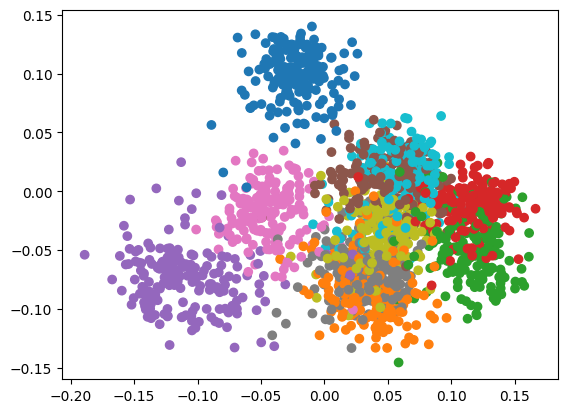

In [27]:
Vfinal = Winvhalf @ Vtilde[:, -(K-1):]

Z = Xtilde @ Vfinal[:, ::-1]
colors = plt.cm.tab10(np.arange(K))

# this plots the first two coordinates against each other 
plt.scatter(Z[:,0], Z[:,1], c = colors[Y])

In [29]:
# relationship with CCA
X = digits.data
Y = digits.target
valuesY, countsY = np.unique(Y, return_counts=True)
K = np.shape(countsY)[0]


In [77]:
Xcent = X - np.mean(X, axis = 0)
Ym = np.eye(K)[Y,:]
Ymcent = Ym - np.mean(Ym, axis = 0)
Cross = Xcent.T @ Ym 
SigmaY = Ymcent.T @ Ymcent
SigmaX = Xcent.T @ Xcent
UY, sY, VtY = np.linalg.svd(SigmaY, full_matrices=False) 
UX, sX, VtX = np.linalg.svd(SigmaX, full_matrices=False)
selX = sX > 1E-6
selY = sY > 1E-6
SigmaXinvhalf = (UX[:,selX] * 1/np.sqrt(sX[selX])) @ (VtX.T[:,selX]).T
SigmaYinvhalf = (UY[:,selY] * 1/np.sqrt(sY[selY])) @ (VtY.T[:,selY]).T
Crosstilde = SigmaXinvhalf @ Cross @ SigmaYinvhalf #(Cross /  np.sqrt(countsY))
Utilde, stilde, Vtilde =  np.linalg.svd(Crosstilde, full_matrices=False) 

In [78]:
a = SigmaXinvhalf @ Utilde[:,0]

In [79]:
proj = Xcent @ a

array([[ 1.        , -0.99997567],
       [-0.99997567,  1.        ]])

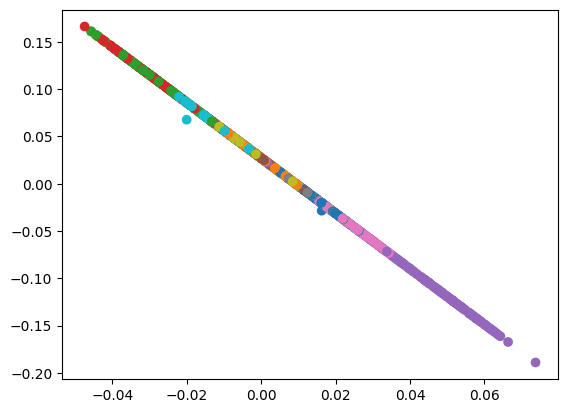

In [80]:
# there is almost a perfect correlation with the first discriminant coordinate and 
# the first canonical variate (from X) as computed in the previous blocks 
plt.scatter(proj, Z[:,0], c = colors[Y])
np.corrcoef(proj, Z[:,0])